In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('cleaned_data.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        720 non-null    object 
 1   company     720 non-null    object 
 2   year        720 non-null    int64  
 3   Price       720 non-null    float64
 4   kms_driven  720 non-null    float64
 5   fuel_type   720 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 33.9+ KB


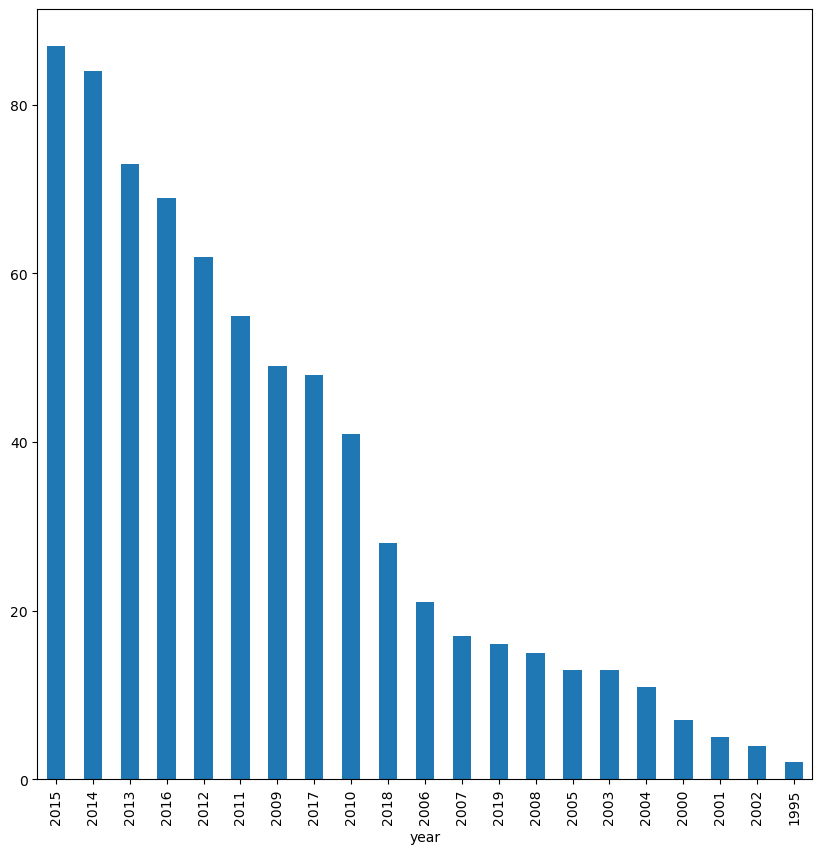

In [7]:
plt.figure(figsize=(10, 10))
counts = df['year'].value_counts()
ax = counts.plot(kind='bar')
plt.show()

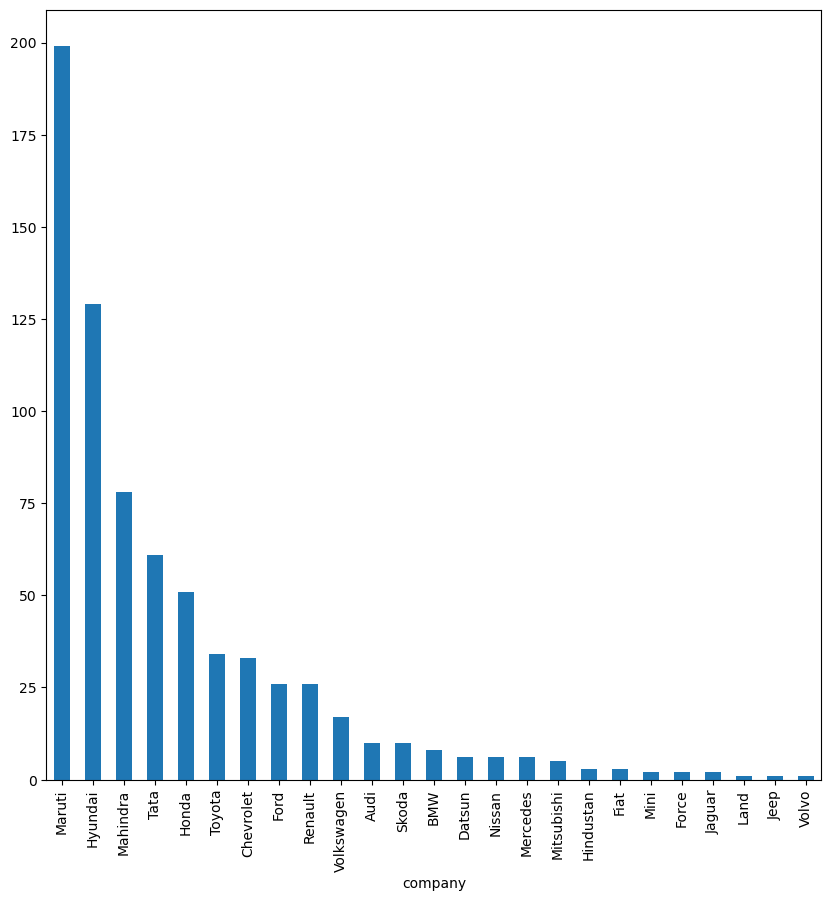

In [6]:
plt.figure(figsize=(10, 10))
counts = df['company'].value_counts()
ax = counts.plot(kind='bar')
plt.show()

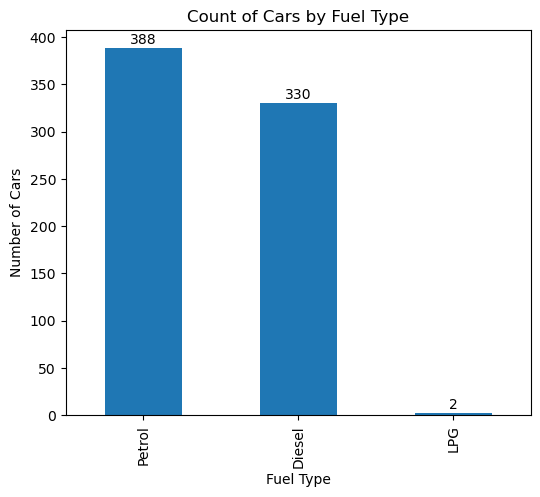

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

counts = df['fuel_type'].value_counts()

ax = counts.plot(kind='bar')

# Add count labels on top of bars
for i, v in enumerate(counts):
    ax.text(i, v + 5, str(v), ha='center')

plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.title("Count of Cars by Fuel Type")
plt.show()

In [14]:
bins = [0, 25000, 50000, 100000, 150000, 200000]
labels = [
    "0-25k",
    "25k-50k",
    "50k-100k",
    "100k-150k",
    "150k-200k"
]

df['kms_group'] = pd.cut(
    df['kms_driven'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

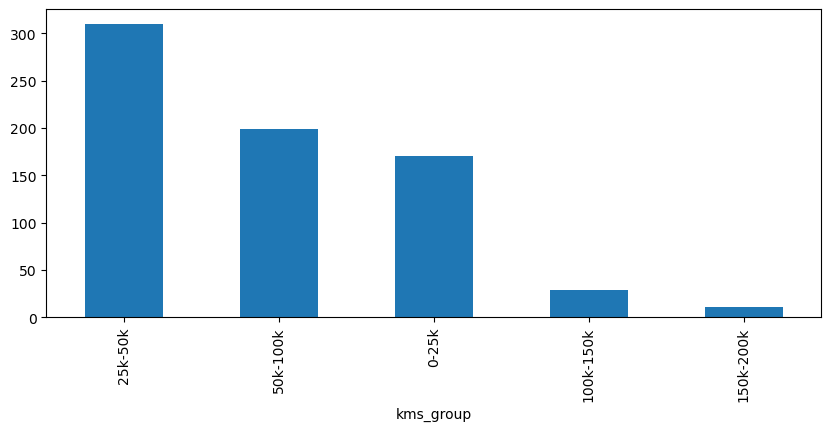

In [21]:
plt.figure(figsize=(10, 4))
counts = df['kms_group'].value_counts()
ax = counts.plot(kind='bar')
plt.show()

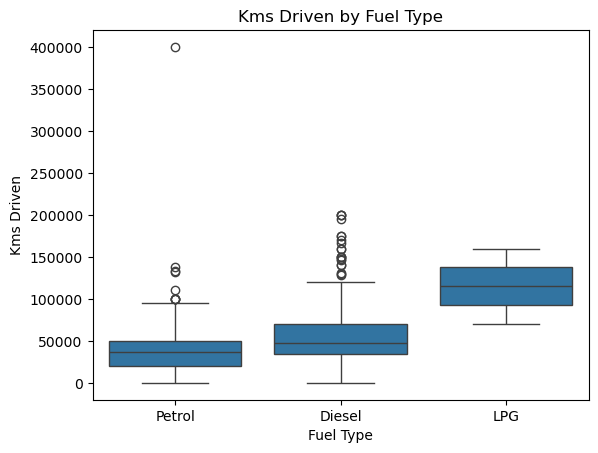

In [22]:
sns.boxplot(x='fuel_type', y='kms_driven', data=df)

plt.title("Kms Driven by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Kms Driven")

plt.show()

In [23]:
df = df[(df['kms_driven'] >= 1000) & (df['kms_driven'] <= 200000)]

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 704 entries, 0 to 719
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   name        704 non-null    object  
 1   company     704 non-null    object  
 2   year        704 non-null    int64   
 3   Price       704 non-null    float64 
 4   kms_driven  704 non-null    float64 
 5   fuel_type   704 non-null    object  
 6   kms_group   704 non-null    category
dtypes: category(1), float64(2), int64(1), object(3)
memory usage: 39.4+ KB


In [25]:
df.to_csv('cleaned_data.csv', index = False)